# 真实信号主线审阅

这本 notebook 只讲当前仓库里**真实已经实现**的信号层：从 `m-sequence`、连续时间码波形、延迟采样，到无噪/加噪接收块 `rx_clean / rx_block`。

主线规则：

- 先讲信号本身怎么长出来。
- 再讲真实代码怎么把这些量组合成接收块。
- `BOC / BCS` 只放在附录，明确标注为概念演示，不是当前仓库可执行实现。
- 各种 `tau_*` 不作为主线起点，只在后半段作为“为什么码会被延迟采样”的必要解释出现。

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib
import numpy as np

from nav_ka.legacy import ka_multifreq_receiver_common as KA
from nav_ka.studies import issue_03_textbook_correction as ISSUE03

# ISSUE03 模块在脚本模式下会把 backend 设成 Agg；
# notebook 里显式切回 inline。
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import matplotlib.pyplot as plt

plt.switch_backend('module://matplotlib_inline.backend_inline')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Songti SC', 'STHeiti', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['font.size'] = 10

FC_HZ = 22.5e9
TRACE_RNG_SEED = 2026
BLOCK_SAMPLES = 1200

def circular_autocorr_pm1(seq: np.ndarray) -> np.ndarray:
    seq = np.asarray(seq, dtype=float)
    n = len(seq)
    out = np.empty(n, dtype=float)
    for k in range(n):
        out[k] = np.dot(seq, np.roll(seq, -k)) / n
    return out

def triangular_acf(tau: np.ndarray, tc: float, amplitude: float = 1.0) -> np.ndarray:
    tau = np.asarray(tau, dtype=float)
    out = np.zeros_like(tau)
    mask = np.abs(tau) <= tc
    out[mask] = amplitude * (1.0 - np.abs(tau[mask]) / tc)
    return out

def sinc_sq_psd(f_hz: np.ndarray, tc: float, amplitude: float = 1.0) -> np.ndarray:
    return amplitude * tc * np.sinc(f_hz * tc) ** 2

def normalized_sliding_autocorr(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    corr = np.correlate(x, x, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    corr = corr / np.max(np.abs(corr))
    return lags, corr

def square_subcarrier(t: np.ndarray, fs_hz: float, phase_rad: float = 0.0) -> np.ndarray:
    raw = np.sin(2.0 * np.pi * fs_hz * t + phase_rad)
    return np.where(raw >= 0.0, 1.0, -1.0)

def boc_like_waveform(code_waveform: np.ndarray, t: np.ndarray, fs_hz: float, phase_rad: float = 0.0) -> np.ndarray:
    return np.asarray(code_waveform, dtype=float) * square_subcarrier(np.asarray(t), fs_hz, phase_rad)

def bcs_like_waveform(code_chips: np.ndarray, chip_rate_hz: float, template: np.ndarray, oversample: int = 64) -> tuple[np.ndarray, np.ndarray]:
    code_chips = np.asarray(code_chips, dtype=float)
    template = np.asarray(template, dtype=float)
    chip_period = 1.0 / chip_rate_hz
    sub_period = chip_period / len(template)
    total = len(code_chips) * len(template) * oversample
    t = np.arange(total) * (sub_period / oversample)
    chip_idx = np.floor(t / chip_period).astype(int)
    chip_idx = np.clip(chip_idx, 0, len(code_chips) - 1)
    within_chip = np.mod(t, chip_period)
    template_idx = np.floor(within_chip / sub_period).astype(int)
    template_idx = np.clip(template_idx, 0, len(template) - 1)
    waveform = code_chips[chip_idx] * template[template_idx]
    return t, waveform


## 1. 当前真实 PRN 码是什么

这一步只看一个事实：当前仓库真实信号链里的码来自 `mseq_7()`。

这一节不先谈传播、不先谈时延，只先回答三个最基本的问题：

- 码长是多少。
- 取值是什么。
- 一个周期结束之后它是怎么重复的。

{'code_length': 127, 'sum_over_period': 1.0, 'unique_values': [-1.0, 1.0], 'chip_rate_hz': 50000.0}


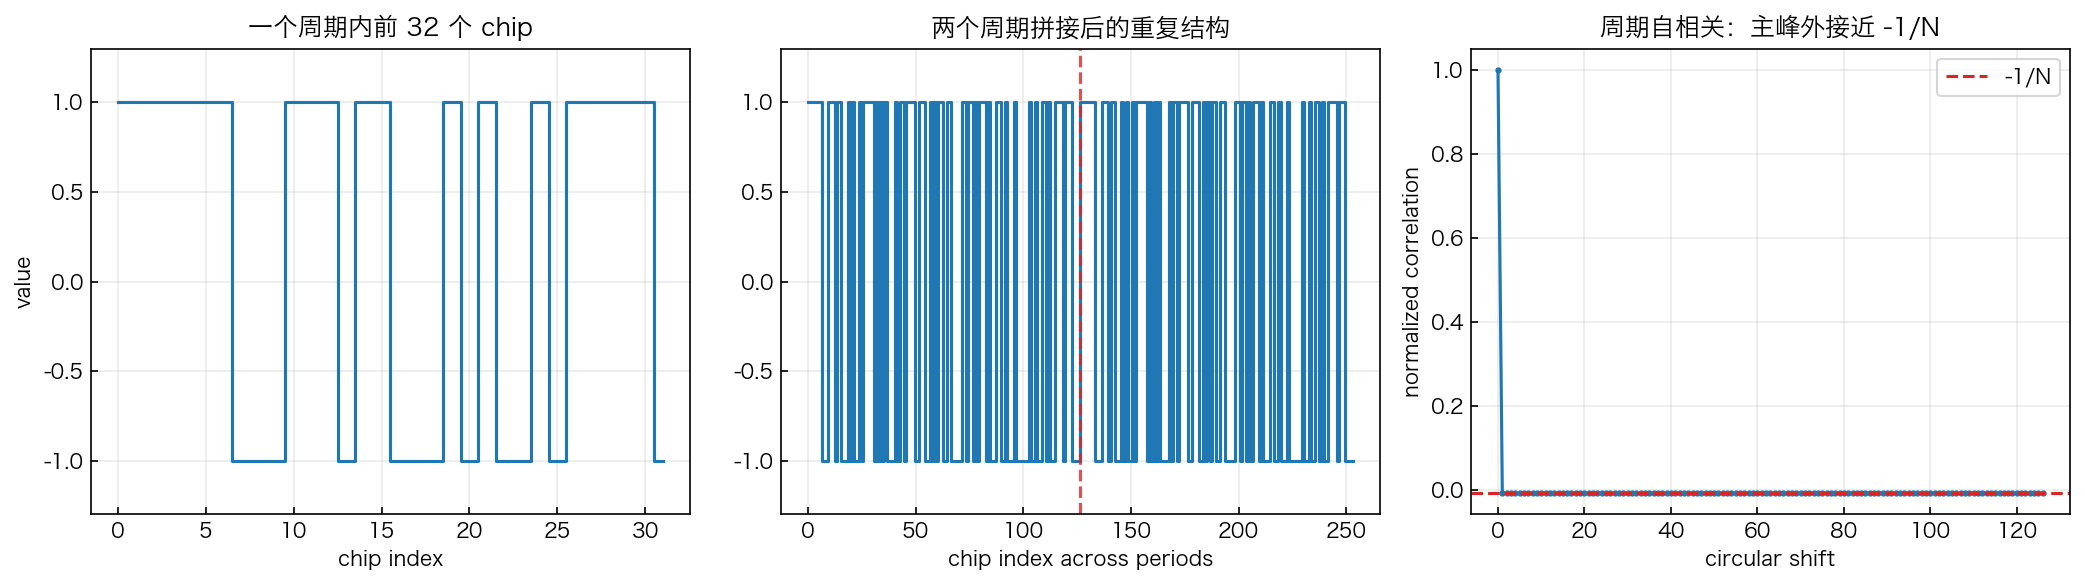

In [2]:
code = KA.mseq_7().astype(float)
n = len(code)
code_two_periods = np.tile(code, 2)
cacf = circular_autocorr_pm1(code)

print({
    'code_length': n,
    'sum_over_period': float(np.sum(code)),
    'unique_values': np.unique(code).tolist(),
    'chip_rate_hz': KA.DEFAULT_CHIP_RATE_HZ,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].step(np.arange(32), code[:32], where='mid')
axes[0].set_title('一个周期内前 32 个 chip')
axes[0].set_xlabel('chip index')
axes[0].set_ylabel('value')
axes[0].set_ylim(-1.3, 1.3)

axes[1].step(np.arange(2 * n), code_two_periods, where='mid')
axes[1].axvline(n - 0.5, color='tab:red', ls='--', alpha=0.8)
axes[1].set_title('两个周期拼接后的重复结构')
axes[1].set_xlabel('chip index across periods')
axes[1].set_ylim(-1.3, 1.3)

axes[2].plot(np.arange(n), cacf, marker='o', ms=2)
axes[2].axhline(-1.0 / n, color='tab:red', ls='--', label='-1/N')
axes[2].set_title('周期自相关：主峰外接近 -1/N')
axes[2].set_xlabel('circular shift')
axes[2].set_ylabel('normalized correlation')
axes[2].legend()

fig.tight_layout()
plt.show()


## 2. 从离散码到连续时间码波形

真实代码不是只拿一个 `±1` 数组就结束了，接收块里真正要用的是连续时间上的 `c(t)`。

当前仓库用 `sample_code_waveform()` 做这件事。核心含义是：

- 码按一个周期不断重复。
- 每个 chip 在时间上是矩形脉冲。
- 给定任意连续时间 `t`，函数会算出此刻落在哪个 chip 上。

{'chip_period_s': 2e-05, 'code_period_s': 0.00254, 'samples_one_chip_demo': 500}


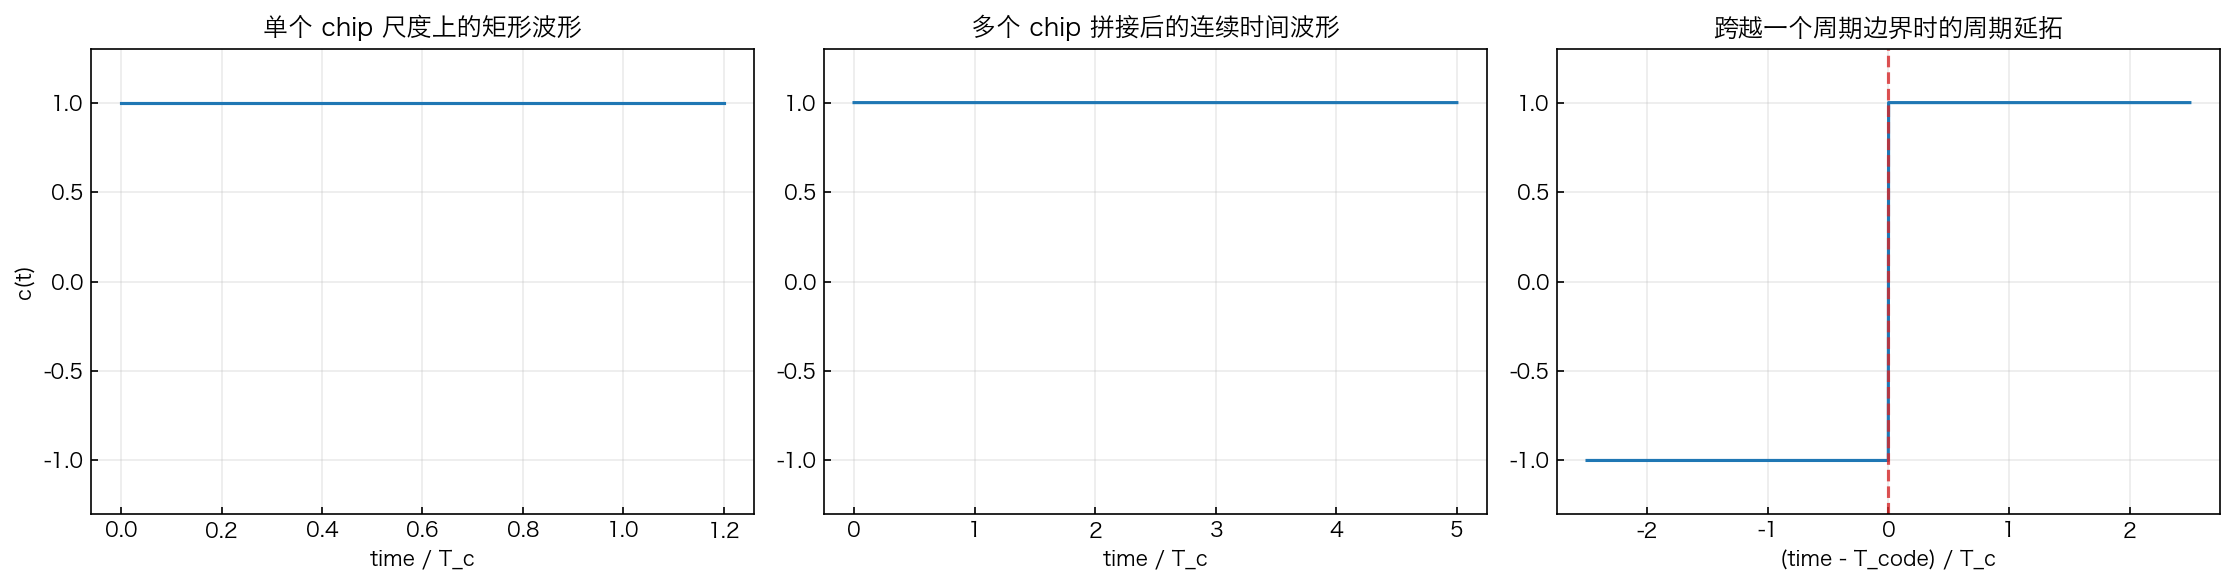

In [3]:
chip_rate_hz = KA.DEFAULT_CHIP_RATE_HZ
tc = 1.0 / chip_rate_hz
code_period_s = len(code) / chip_rate_hz

t_one_chip = np.linspace(0.0, 1.2 * tc, 500)
wave_one_chip = KA.sample_code_waveform(code, chip_rate_hz, t_one_chip).real

t_five_chip = np.linspace(0.0, 5.0 * tc, 1500)
wave_five_chip = KA.sample_code_waveform(code, chip_rate_hz, t_five_chip).real

t_cross_period = np.linspace(code_period_s - 2.5 * tc, code_period_s + 2.5 * tc, 2000)
wave_cross_period = KA.sample_code_waveform(code, chip_rate_hz, t_cross_period).real

print({
    'chip_period_s': tc,
    'code_period_s': code_period_s,
    'samples_one_chip_demo': len(t_one_chip),
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_one_chip / tc, wave_one_chip)
axes[0].set_title('单个 chip 尺度上的矩形波形')
axes[0].set_xlabel('time / T_c')
axes[0].set_ylabel('c(t)')
axes[0].set_ylim(-1.3, 1.3)

axes[1].plot(t_five_chip / tc, wave_five_chip)
axes[1].set_title('多个 chip 拼接后的连续时间波形')
axes[1].set_xlabel('time / T_c')
axes[1].set_ylim(-1.3, 1.3)

axes[2].plot((t_cross_period - code_period_s) / tc, wave_cross_period)
axes[2].axvline(0.0, color='tab:red', ls='--', alpha=0.8)
axes[2].set_title('跨越一个周期边界时的周期延拓')
axes[2].set_xlabel('(time - T_code) / T_c')
axes[2].set_ylim(-1.3, 1.3)

fig.tight_layout()
plt.show()


## 3. 什么叫延迟采样

这一步先不引入真实传播背景，只做一个纯信号层演示：`c(t)` 和 `c(t - \tau)` 到底有什么区别。

这样做的目的只有一个：后面看到 `delayed_code = sample_code_waveform(..., t - tau_total)` 时，不会再觉得它是一个突然冒出来的黑箱。

{'tau_demo_1_in_chip': 0.35, 'tau_demo_2_in_chip': 1.2}


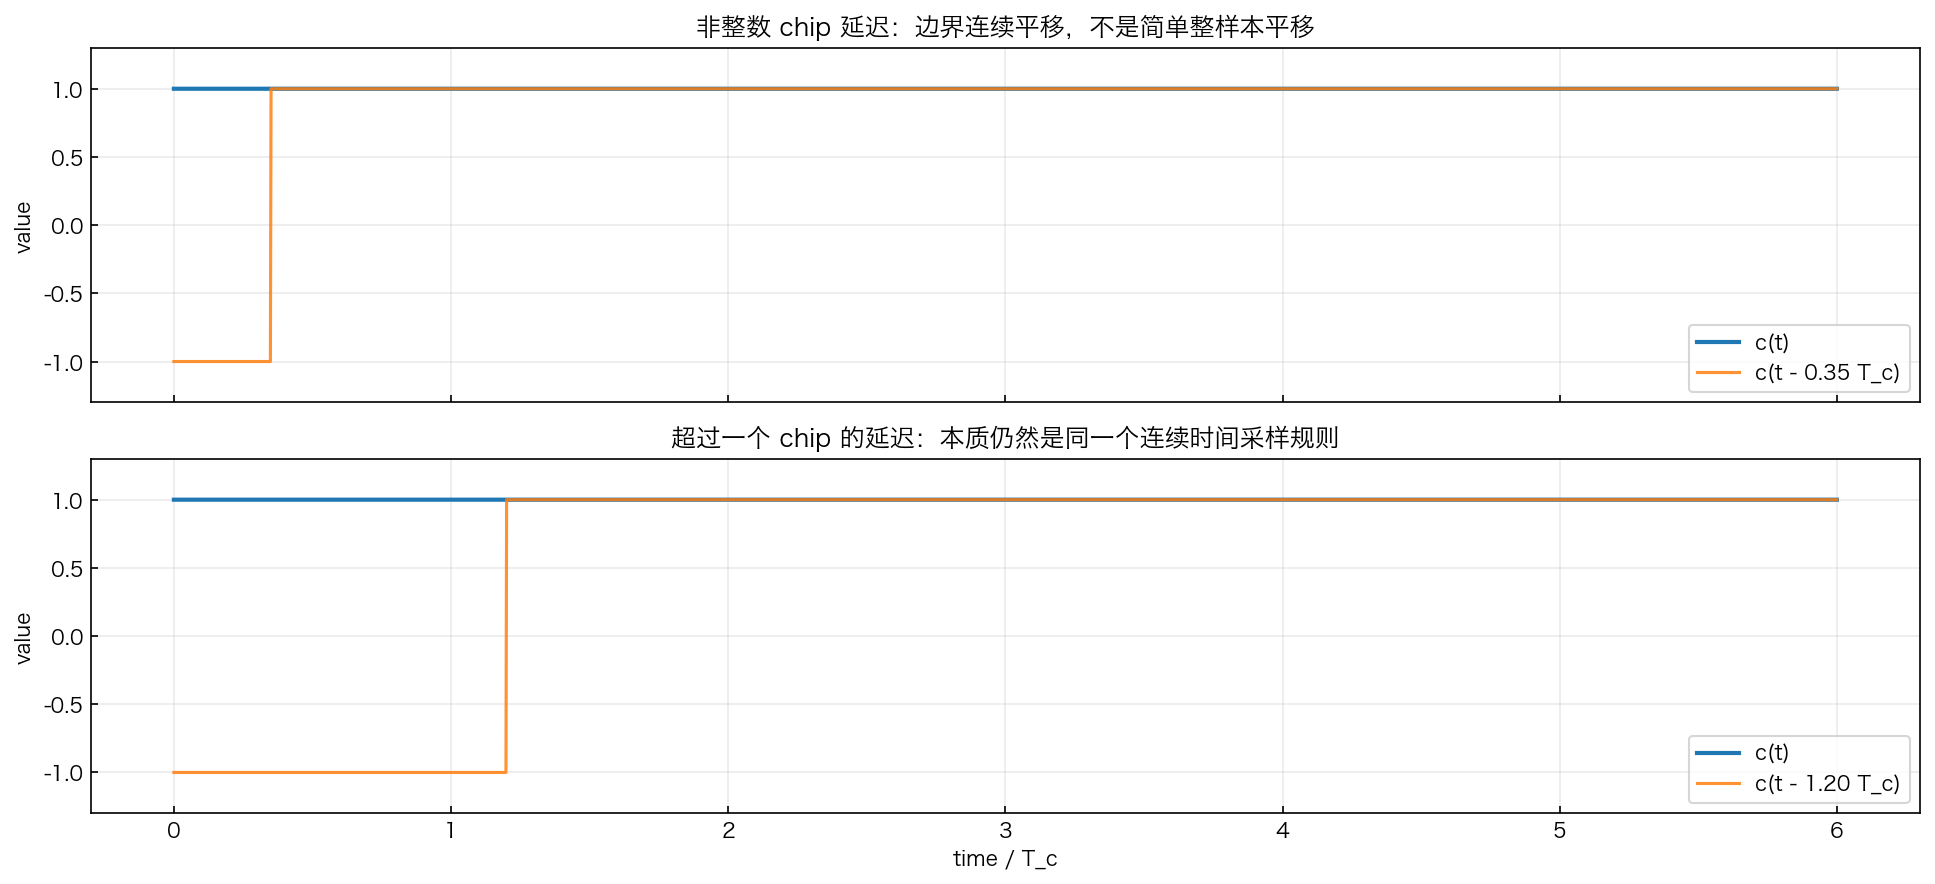

In [4]:
t_demo = np.linspace(0.0, 6.0 * tc, 2500)
tau_demo_1 = 0.35 * tc
tau_demo_2 = 1.20 * tc

wave_ref = KA.sample_code_waveform(code, chip_rate_hz, t_demo).real
wave_delay_1 = KA.sample_code_waveform(code, chip_rate_hz, t_demo - tau_demo_1).real
wave_delay_2 = KA.sample_code_waveform(code, chip_rate_hz, t_demo - tau_demo_2).real

print({
    'tau_demo_1_in_chip': tau_demo_1 / tc,
    'tau_demo_2_in_chip': tau_demo_2 / tc,
})

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(t_demo / tc, wave_ref, label='c(t)', lw=2)
axes[0].plot(t_demo / tc, wave_delay_1, label=f'c(t - {tau_demo_1 / tc:.2f} T_c)', alpha=0.85)
axes[0].set_title('非整数 chip 延迟：边界连续平移，不是简单整样本平移')
axes[0].set_ylabel('value')
axes[0].set_ylim(-1.3, 1.3)
axes[0].legend()

axes[1].plot(t_demo / tc, wave_ref, label='c(t)', lw=2)
axes[1].plot(t_demo / tc, wave_delay_2, label=f'c(t - {tau_demo_2 / tc:.2f} T_c)', alpha=0.85)
axes[1].set_title('超过一个 chip 的延迟：本质仍然是同一个连续时间采样规则')
axes[1].set_xlabel('time / T_c')
axes[1].set_ylabel('value')
axes[1].set_ylim(-1.3, 1.3)
axes[1].legend()

fig.tight_layout()
plt.show()


## 4. 为什么矩形 chip 最终会指向三角相关和 sinc² 频谱

这一步仍然是信号层，不是传播层。

这里不是在调用某个仓库里的“理论公式 API”，而是用教学可视化把后续测距意义接上：

- 矩形 chip 的重叠面积线性变化，所以相关主峰是三角形。
- 矩形 chip 的频域是 `sinc`，所以功率谱密度是 `sinc²`。

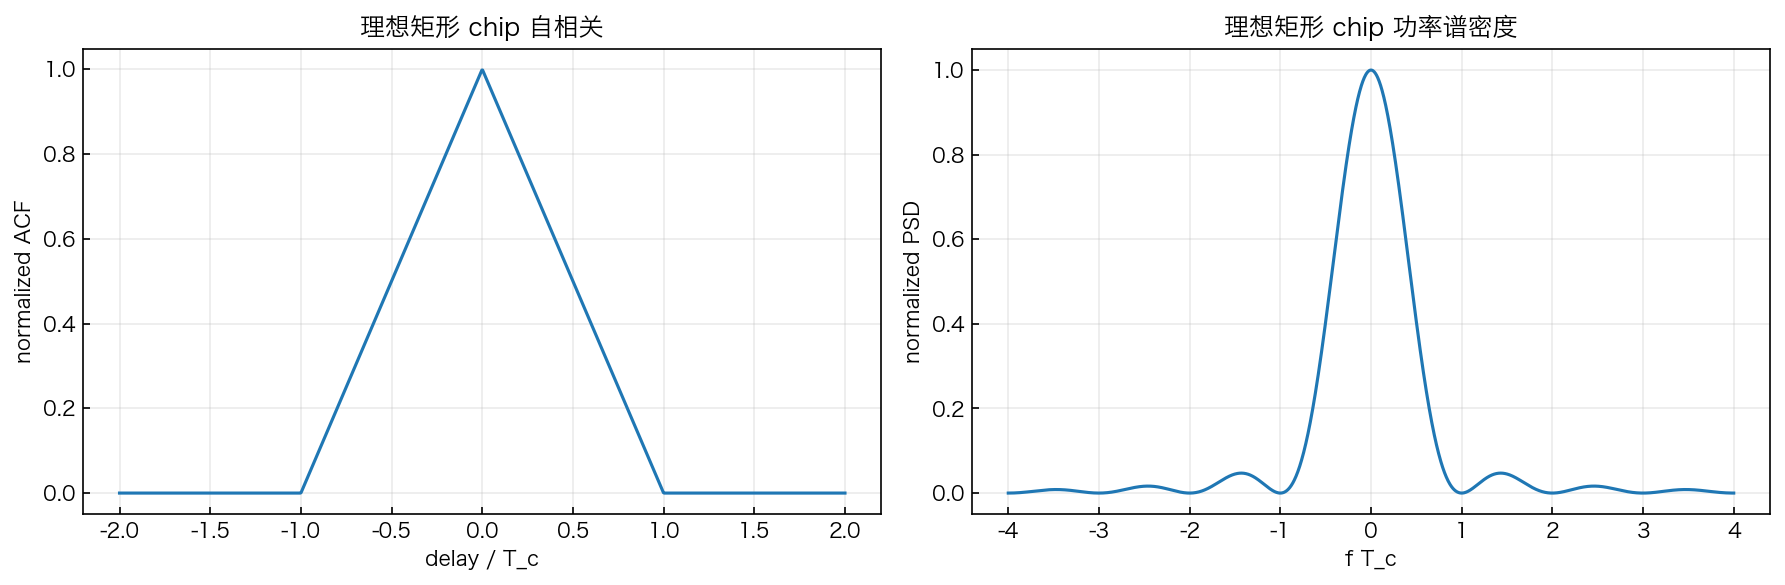

In [5]:
tau = np.linspace(-2.0 * tc, 2.0 * tc, 1000)
f_hz = np.linspace(-4.0 / tc, 4.0 / tc, 2000)
acf = triangular_acf(tau, tc)
psd = sinc_sq_psd(f_hz, tc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tau / tc, acf)
axes[0].set_title('理想矩形 chip 自相关')
axes[0].set_xlabel('delay / T_c')
axes[0].set_ylabel('normalized ACF')

axes[1].plot(f_hz * tc, psd / np.max(psd))
axes[1].set_title('理想矩形 chip 功率谱密度')
axes[1].set_xlabel('f T_c')
axes[1].set_ylabel('normalized PSD')

fig.tight_layout()
plt.show()


## 5. 当前真实接收机时间网格和信号配置

到这里才开始进入当前仓库的真实 Ka 信号链。

这一节只做准备，不先画复杂结果：

- 从默认场构造真实 WKB 结果。
- 构造当前信号配置 `SignalConfig`。
- 建立接收机离散时间网格。

In [6]:
field_result = KA.build_default_field_context()
t_eval = np.asarray(field_result['t_eval'], dtype=float)
z_eval = np.asarray(field_result['z_eval'], dtype=float)
ne_combined = np.asarray(field_result['ne_combined'], dtype=float)

wkb_result = KA.compute_real_wkb_series(
    t_eval=t_eval,
    z_eval=z_eval,
    ne_matrix=ne_combined,
    fc_hz=FC_HZ,
    nu_en_hz=KA.DEFAULT_NU_EN_HZ,
    delta_f_hz=KA.DEFAULT_DELTA_F_HZ,
    verbose=False,
)

cfg_sig_legacy = KA.build_default_signal_config(fc_hz=FC_HZ, wkb_time_s=wkb_result['wkb_time_s'])
cfg_motion = KA.build_default_motion_config()
rx_time_s = np.arange(cfg_sig_legacy.total_samples) / cfg_sig_legacy.fs_hz
plasma_rx = KA.resample_wkb_to_receiver_time(
    rx_time_s=rx_time_s,
    wkb_time_s=wkb_result['wkb_time_s'],
    A_t=wkb_result['A_t'],
    phi_t=wkb_result['phi_t'],
    tau_g_t=wkb_result['tau_g_t'],
)
code_chips = KA.build_transmitter_signal_tools(cfg_sig_legacy)['code_chips']
t_block_s = np.arange(min(BLOCK_SAMPLES, cfg_sig_legacy.total_samples)) / cfg_sig_legacy.fs_hz

print({
    'fc_ghz': FC_HZ / 1e9,
    'fs_hz': cfg_sig_legacy.fs_hz,
    'chip_rate_hz': cfg_sig_legacy.chip_rate_hz,
    'samples_per_chip': cfg_sig_legacy.samples_per_chip,
    'chip_period_s': cfg_sig_legacy.chip_period_s,
    'code_period_s': cfg_sig_legacy.code_period_s,
    'total_samples': cfg_sig_legacy.total_samples,
    'block_samples_used_here': len(t_block_s),
})



[接收机时间轴构造]
  - 真实 WKB 时长 T_real = 21.908328000 s
  - 接收机采样率 fs = 500000.000 Hz
  - 离散化后总采样点 N = 10954164
  - 接收机实际使用时长 T_used = 21.908328000 s
  - 离散化误差 = +1.776e-14 s

[步骤 B] 构造 Ka 22.5 GHz 基础 PN/BPSK 发射模型
  - λ = 1.3324 cm
  - 采样率 fs = 500.000 kHz
  - 码率 chip_rate = 50.000 kcps
  - 每码片采样点 = 10
  - 总时长 = 21.908328 s（完全继承真实 WKB 时间范围）
{'fc_ghz': 22.5, 'fs_hz': 500000.0, 'chip_rate_hz': 50000.0, 'samples_per_chip': 10, 'chip_period_s': 2e-05, 'code_period_s': 0.00254, 'total_samples': 10954164, 'block_samples_used_here': 1200}


## 6. 真实接收块里的第一关键量：`delayed_code`

现在主线重新回到信号本身。

在真实代码里，接收块首先不是直接从 `rx_block` 冒出来，而是先形成：

`delayed_code = c(t - tau_total(t))`

这一节先只看这个量长什么样，以及它和“未延迟本地码”差在哪里。

{'tau_total_ns_mean': 346005.26802552957, 'tau_total_ns_span': 9.592116005619713, 'fd_total_hz_mean': 47997.841799999995}


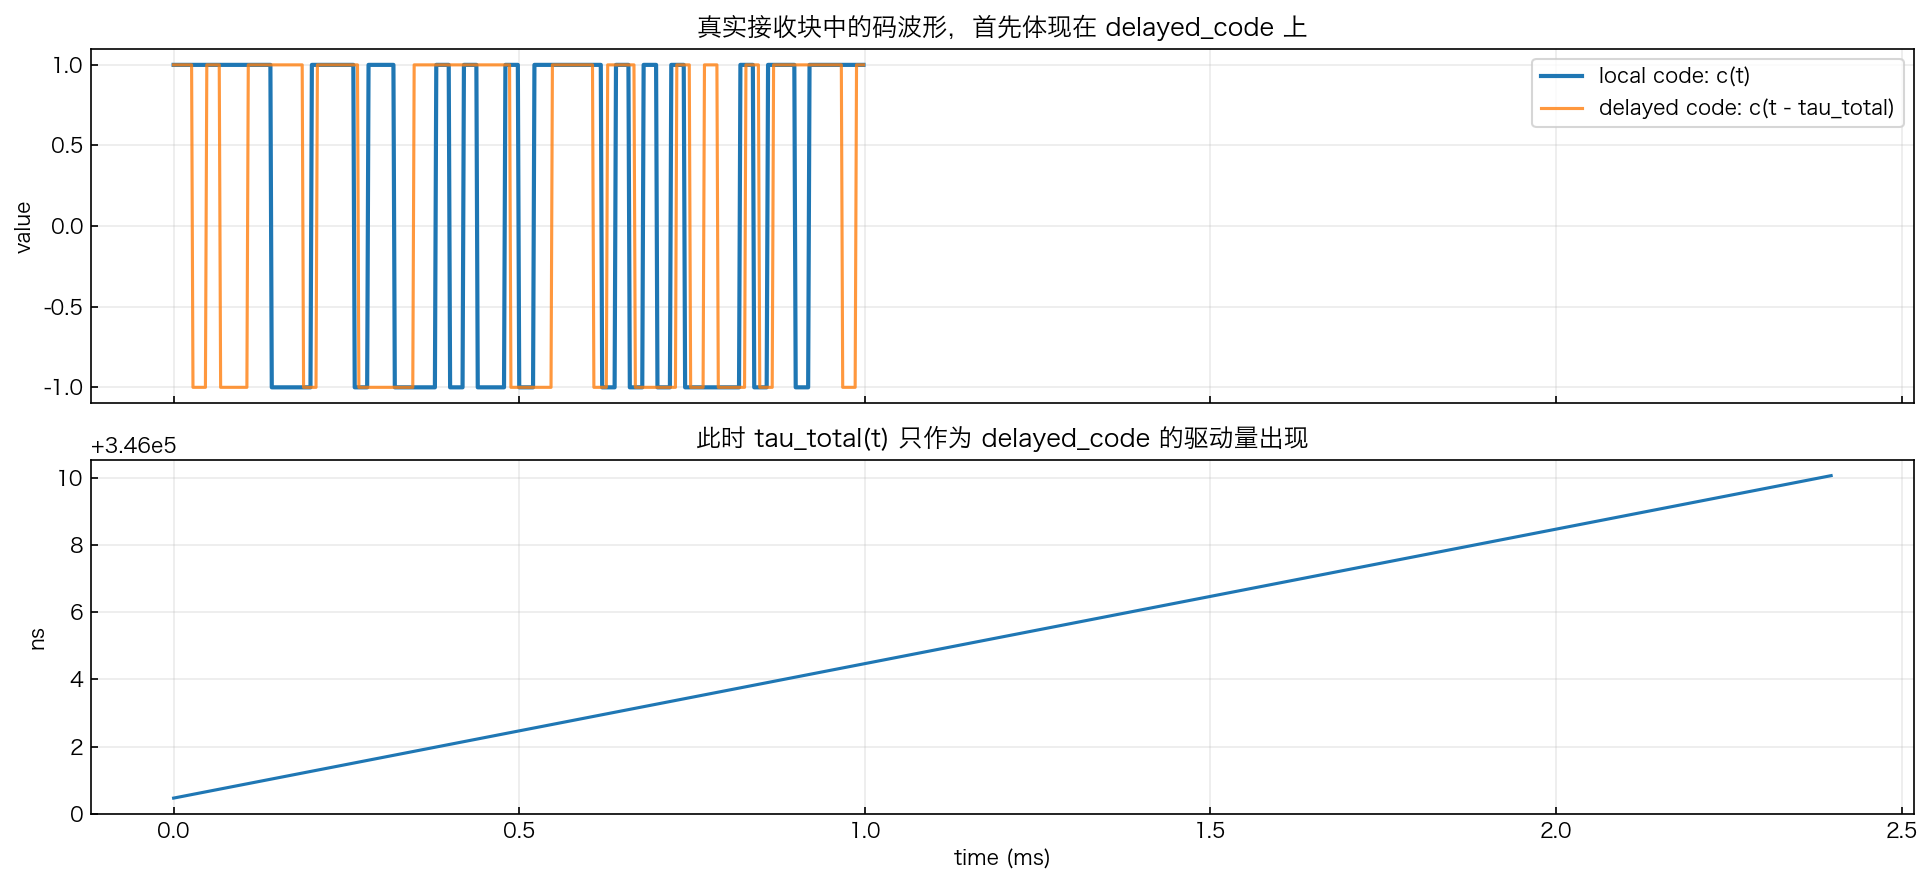

In [7]:
legacy_trace = KA.build_signal_block_trace(
    t_block_s=t_block_s,
    code_chips=code_chips,
    cfg_sig=cfg_sig_legacy,
    cfg_motion=cfg_motion,
    plasma_rx=plasma_rx,
    global_rx_time_s=rx_time_s,
    rng=np.random.default_rng(TRACE_RNG_SEED),
)
local_code_no_delay = KA.sample_code_waveform(code_chips, cfg_sig_legacy.chip_rate_hz, t_block_s)

print({
    'tau_total_ns_mean': float(np.mean(legacy_trace.tau_total_s) * 1e9),
    'tau_total_ns_span': float((np.max(legacy_trace.tau_total_s) - np.min(legacy_trace.tau_total_s)) * 1e9),
    'fd_total_hz_mean': float(np.mean(legacy_trace.fd_total_hz)),
})

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(t_block_s[:500] * 1e3, local_code_no_delay[:500].real, label='local code: c(t)', lw=2)
axes[0].plot(t_block_s[:500] * 1e3, legacy_trace.delayed_code[:500].real, label='delayed code: c(t - tau_total)', alpha=0.8)
axes[0].set_title('真实接收块中的码波形，首先体现在 delayed_code 上')
axes[0].set_ylabel('value')
axes[0].legend()

axes[1].plot(t_block_s * 1e3, legacy_trace.tau_total_s * 1e9)
axes[1].set_title('此时 tau_total(t) 只作为 delayed_code 的驱动量出现')
axes[1].set_xlabel('time (ms)')
axes[1].set_ylabel('ns')

fig.tight_layout()
plt.show()


## 7. 从 `delayed_code` 到 `rx_clean`

真实代码接下来再把两类东西乘上去：

- 幅度项 `A(t)`
- 相位项 `exp(j * phase_total(t))`

这一步结束时，还没有噪声，所以得到的是 `rx_clean`。

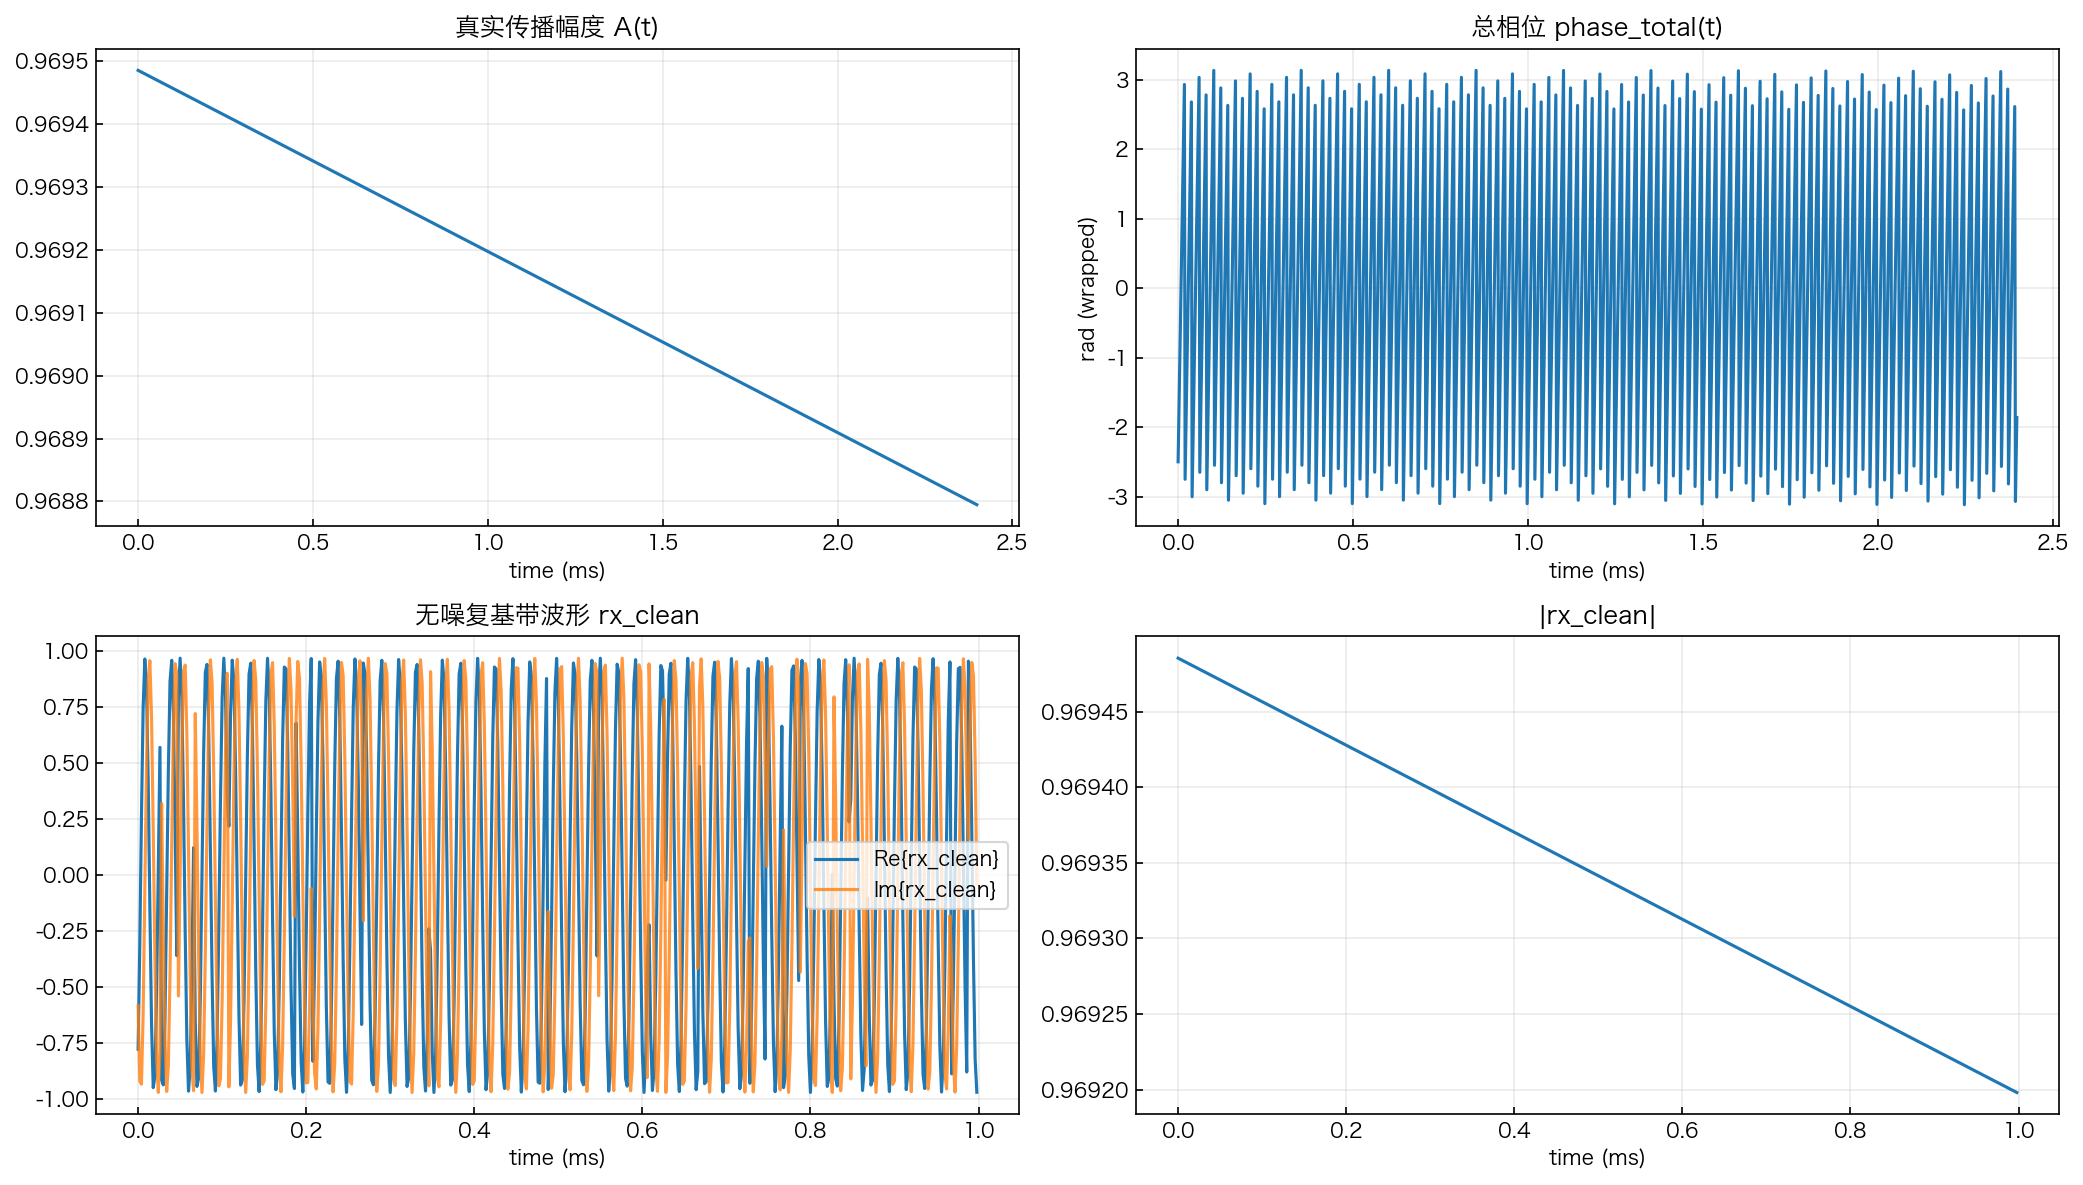

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t_block_s * 1e3, legacy_trace.A_t)
axes[0, 0].set_title('真实传播幅度 A(t)')
axes[0, 0].set_xlabel('time (ms)')

phase_wrapped = np.mod(legacy_trace.phase_total + np.pi, 2.0 * np.pi) - np.pi
axes[0, 1].plot(t_block_s * 1e3, phase_wrapped)
axes[0, 1].set_title('总相位 phase_total(t)')
axes[0, 1].set_xlabel('time (ms)')
axes[0, 1].set_ylabel('rad (wrapped)')

axes[1, 0].plot(t_block_s[:500] * 1e3, legacy_trace.rx_clean[:500].real, label='Re{rx_clean}')
axes[1, 0].plot(t_block_s[:500] * 1e3, legacy_trace.rx_clean[:500].imag, label='Im{rx_clean}', alpha=0.8)
axes[1, 0].set_title('无噪复基带波形 rx_clean')
axes[1, 0].set_xlabel('time (ms)')
axes[1, 0].legend()

axes[1, 1].plot(t_block_s[:500] * 1e3, np.abs(legacy_trace.rx_clean[:500]))
axes[1, 1].set_title('|rx_clean|')
axes[1, 1].set_xlabel('time (ms)')

fig.tight_layout()
plt.show()


## 8. 从 `rx_clean` 到 `rx_block`

到这一步才加入噪声。

也就是说，当前真实接收块的最后一步不是“重新生成一个新信号”，而只是：

`rx_block = rx_clean + noise`

所以这一节要单独把 `noise` 画出来，而不是只给最终结果。

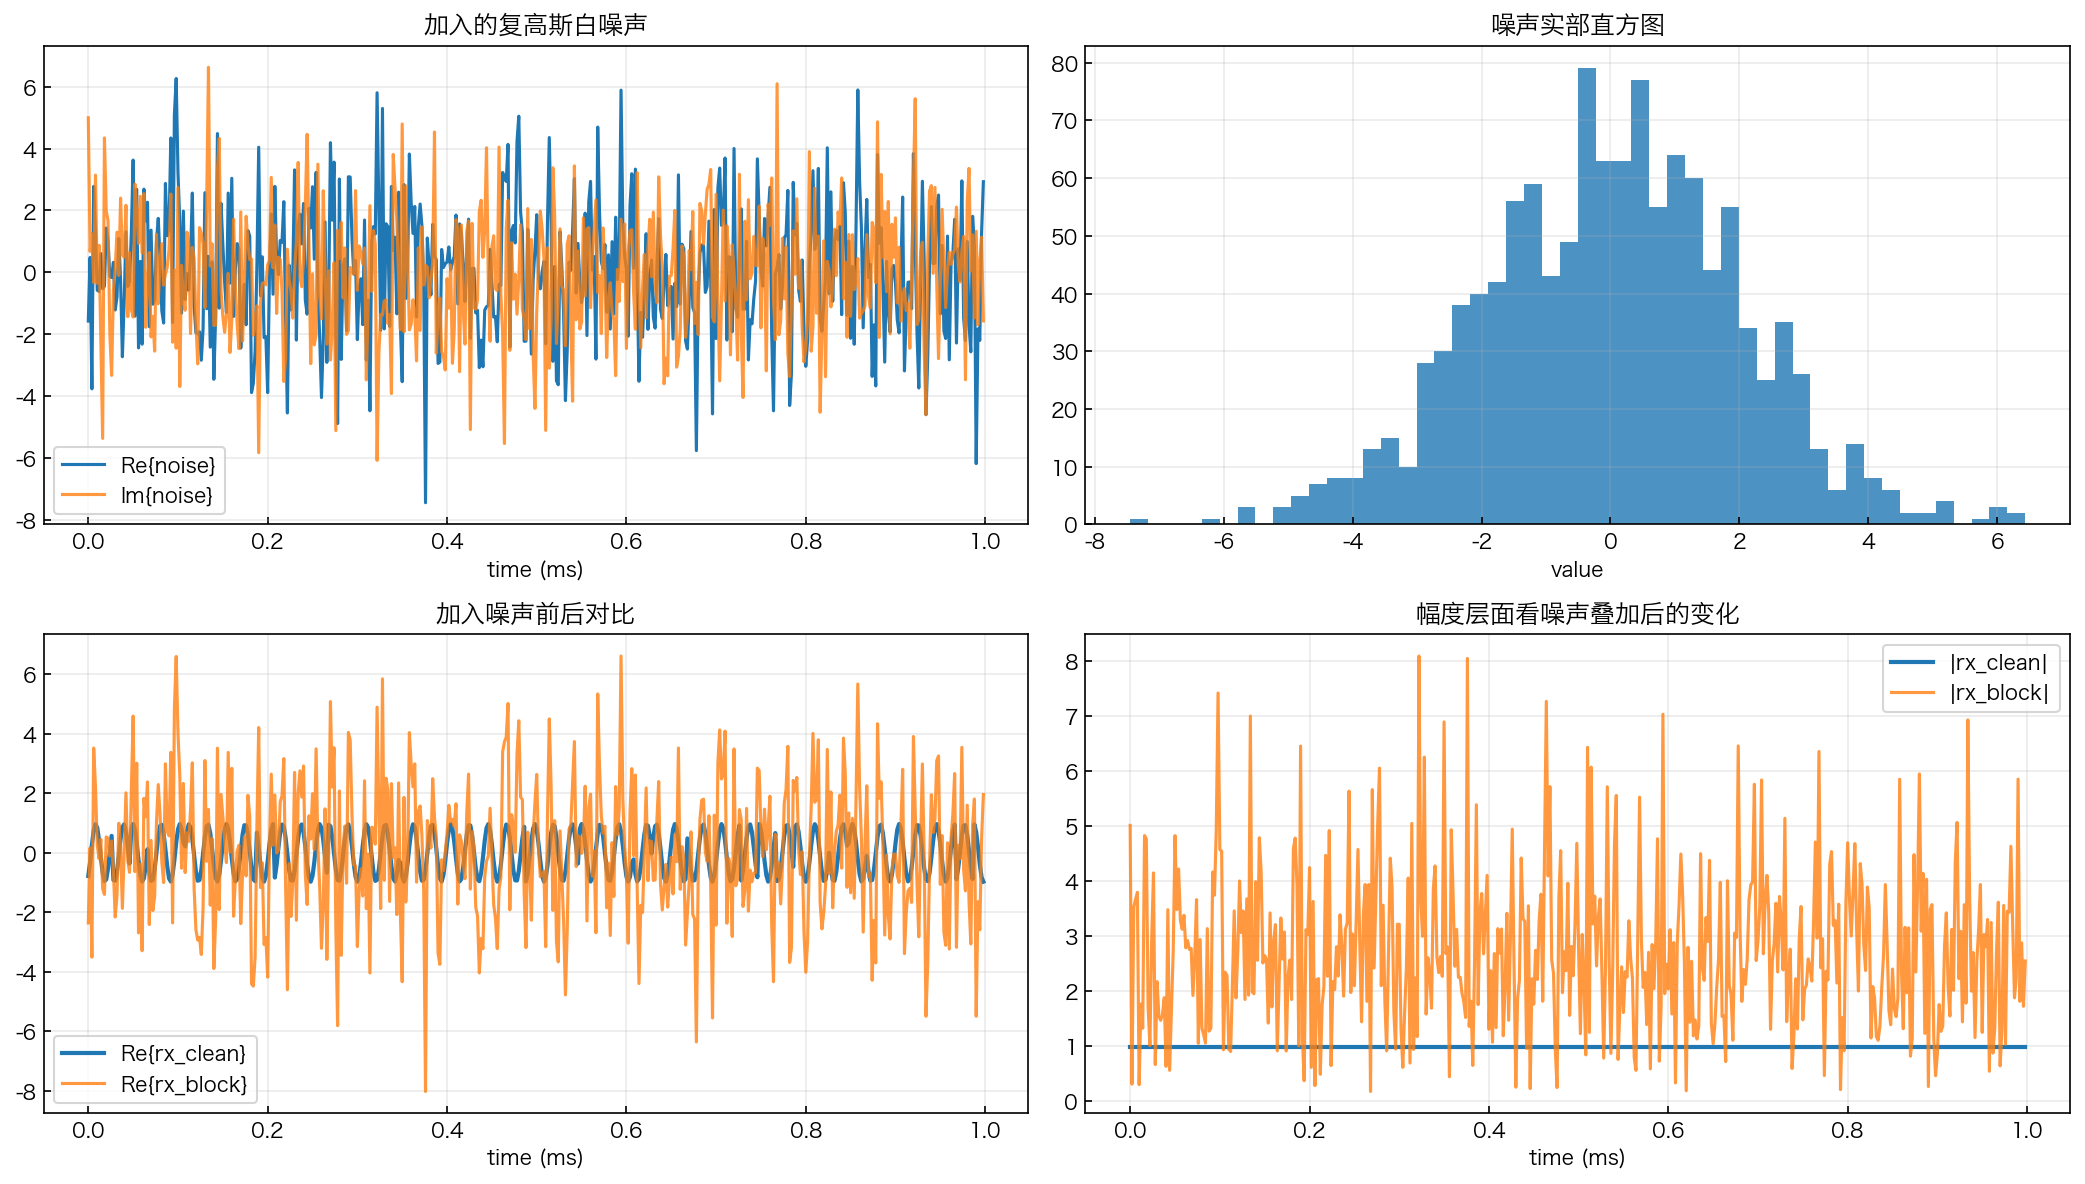

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t_block_s[:500] * 1e3, legacy_trace.noise[:500].real, label='Re{noise}')
axes[0, 0].plot(t_block_s[:500] * 1e3, legacy_trace.noise[:500].imag, label='Im{noise}', alpha=0.8)
axes[0, 0].set_title('加入的复高斯白噪声')
axes[0, 0].set_xlabel('time (ms)')
axes[0, 0].legend()

axes[0, 1].hist(np.real(legacy_trace.noise), bins=50, alpha=0.8)
axes[0, 1].set_title('噪声实部直方图')
axes[0, 1].set_xlabel('value')

axes[1, 0].plot(t_block_s[:500] * 1e3, legacy_trace.rx_clean[:500].real, label='Re{rx_clean}', lw=2)
axes[1, 0].plot(t_block_s[:500] * 1e3, legacy_trace.rx_block[:500].real, label='Re{rx_block}', alpha=0.8)
axes[1, 0].set_title('加入噪声前后对比')
axes[1, 0].set_xlabel('time (ms)')
axes[1, 0].legend()

axes[1, 1].plot(t_block_s[:500] * 1e3, np.abs(legacy_trace.rx_clean[:500]), label='|rx_clean|', lw=2)
axes[1, 1].plot(t_block_s[:500] * 1e3, np.abs(legacy_trace.rx_block[:500]), label='|rx_block|', alpha=0.8)
axes[1, 1].set_title('幅度层面看噪声叠加后的变化')
axes[1, 1].set_xlabel('time (ms)')
axes[1, 1].legend()

fig.tight_layout()
plt.show()


## 9. 最小必要的 `tau_*` 说明

这里不是要把传播物理完整展开，而只是把前面主线里已经用到的 `tau_total` 最小限度解释清楚。

当前真实代码里：

- `tau_geom_s`：来自 `MotionConfig` 的外部线性码时延项。
- `tau_g_s`：来自 WKB 的群时延项。
- `tau_total_s = tau_geom_s + tau_g_s`：它们相加之后进入 `c(t - tau_total)`。

现在才讲这一步，是因为主线重点仍然是“信号怎么被延迟采样并形成接收块”，不是先把传播故事讲满。

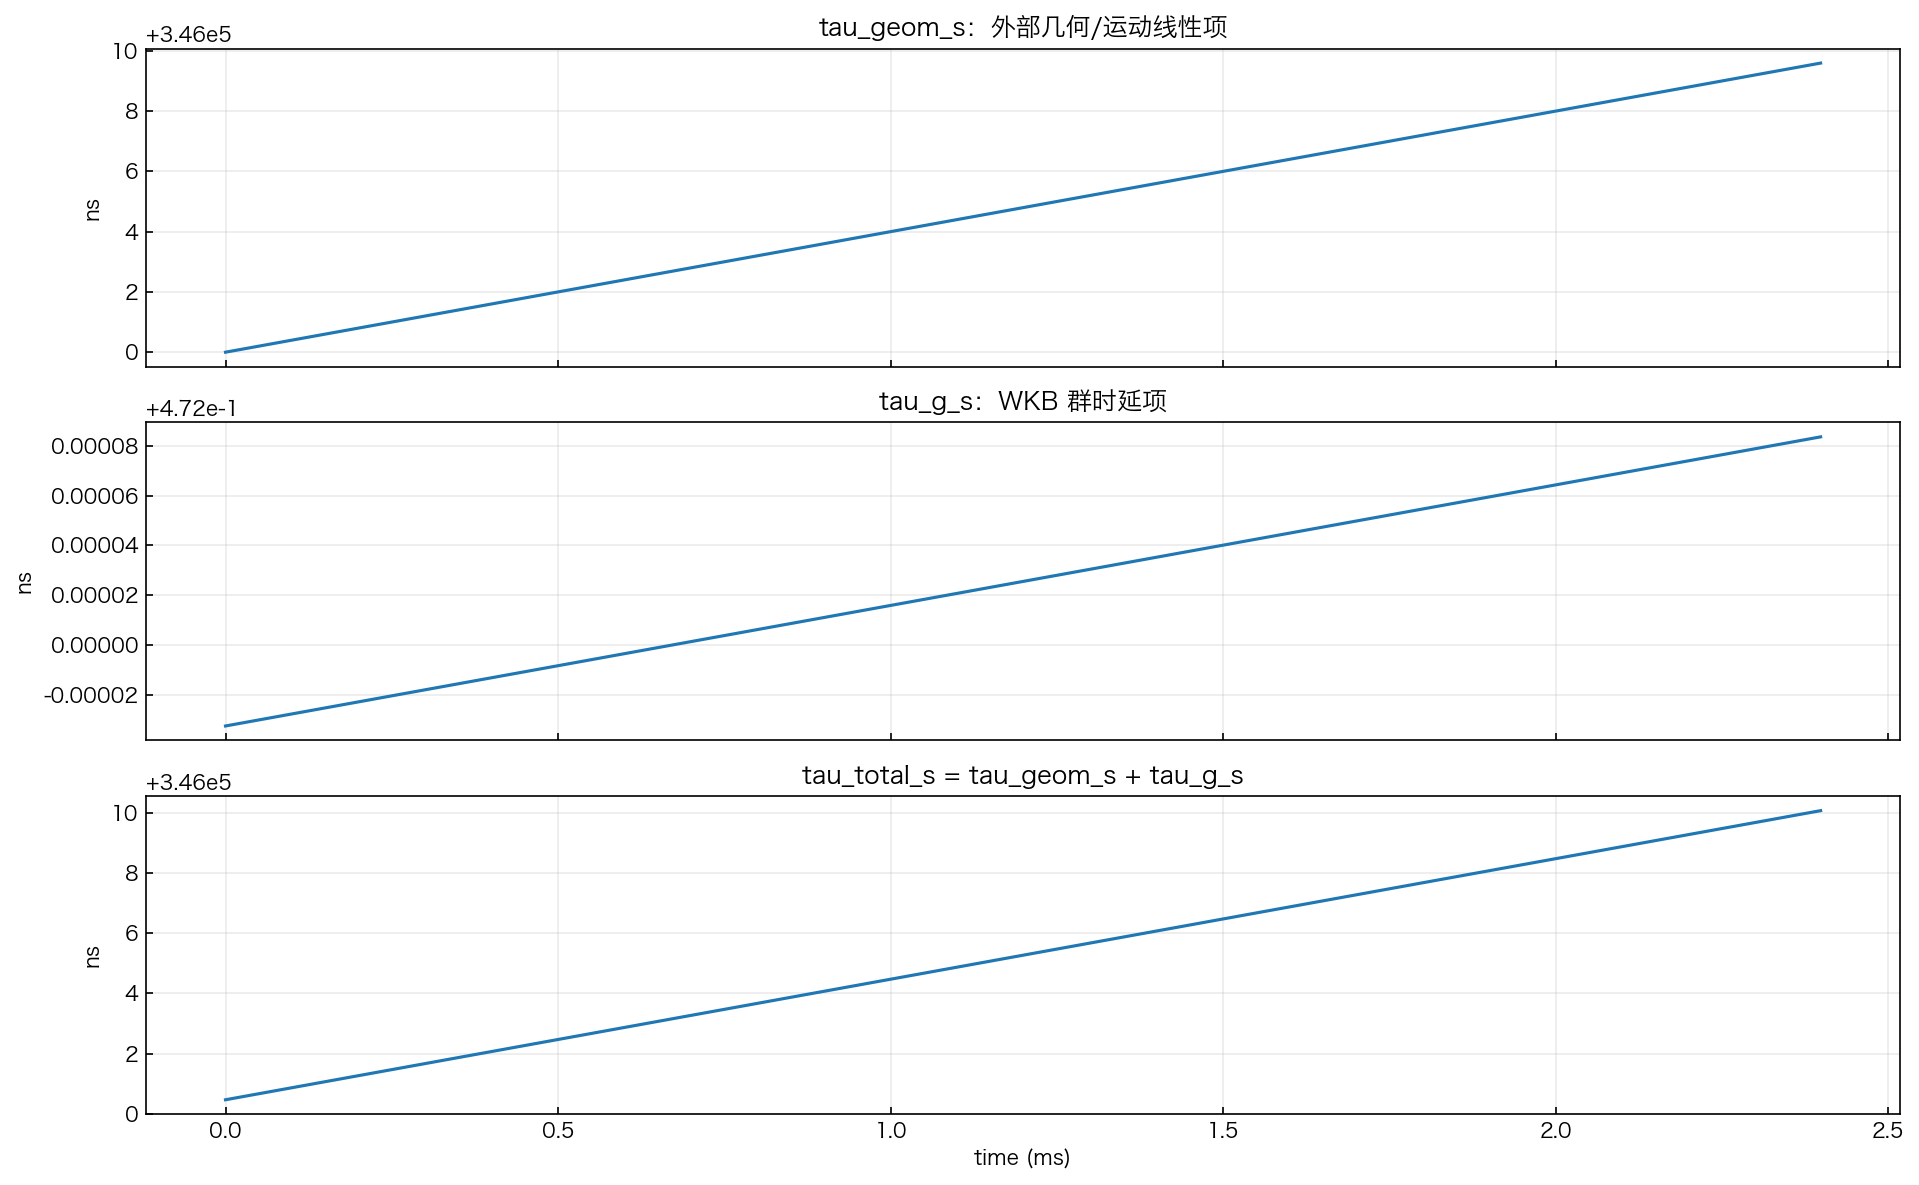

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(t_block_s * 1e3, legacy_trace.tau_geom_s * 1e9)
axes[0].set_title('tau_geom_s：外部几何/运动线性项')
axes[0].set_ylabel('ns')

axes[1].plot(t_block_s * 1e3, legacy_trace.tau_g_s * 1e9)
axes[1].set_title('tau_g_s：WKB 群时延项')
axes[1].set_ylabel('ns')

axes[2].plot(t_block_s * 1e3, legacy_trace.tau_total_s * 1e9)
axes[2].set_title('tau_total_s = tau_geom_s + tau_g_s')
axes[2].set_xlabel('time (ms)')
axes[2].set_ylabel('ns')

fig.tight_layout()
plt.show()


## 10. Issue 03：数据位只是额外乘在码上

这一节只讲一个非常具体的事实：Issue 03 不是重新发明另一套时延，而是在当前码和相位结构上，再乘一个 `delayed_data`。

所以：

- 码的延迟采样逻辑不变。
- `tau_total` 的来源不变。
- 变化的是 `rx_clean = A * delayed_data * delayed_code * exp(j phase_total)`。


[接收机时间轴构造]
  - 真实 WKB 时长 T_real = 21.908328000 s
  - 接收机采样率 fs = 500000.000 Hz
  - 离散化后总采样点 N = 10954164
  - 接收机实际使用时长 T_used = 21.908328000 s
  - 离散化误差 = +1.776e-14 s
{'bit_rate_bps': 50.0, 'bit_period_s': 0.02, 'nav_symbols_preview': [1.0, -1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1.0]}


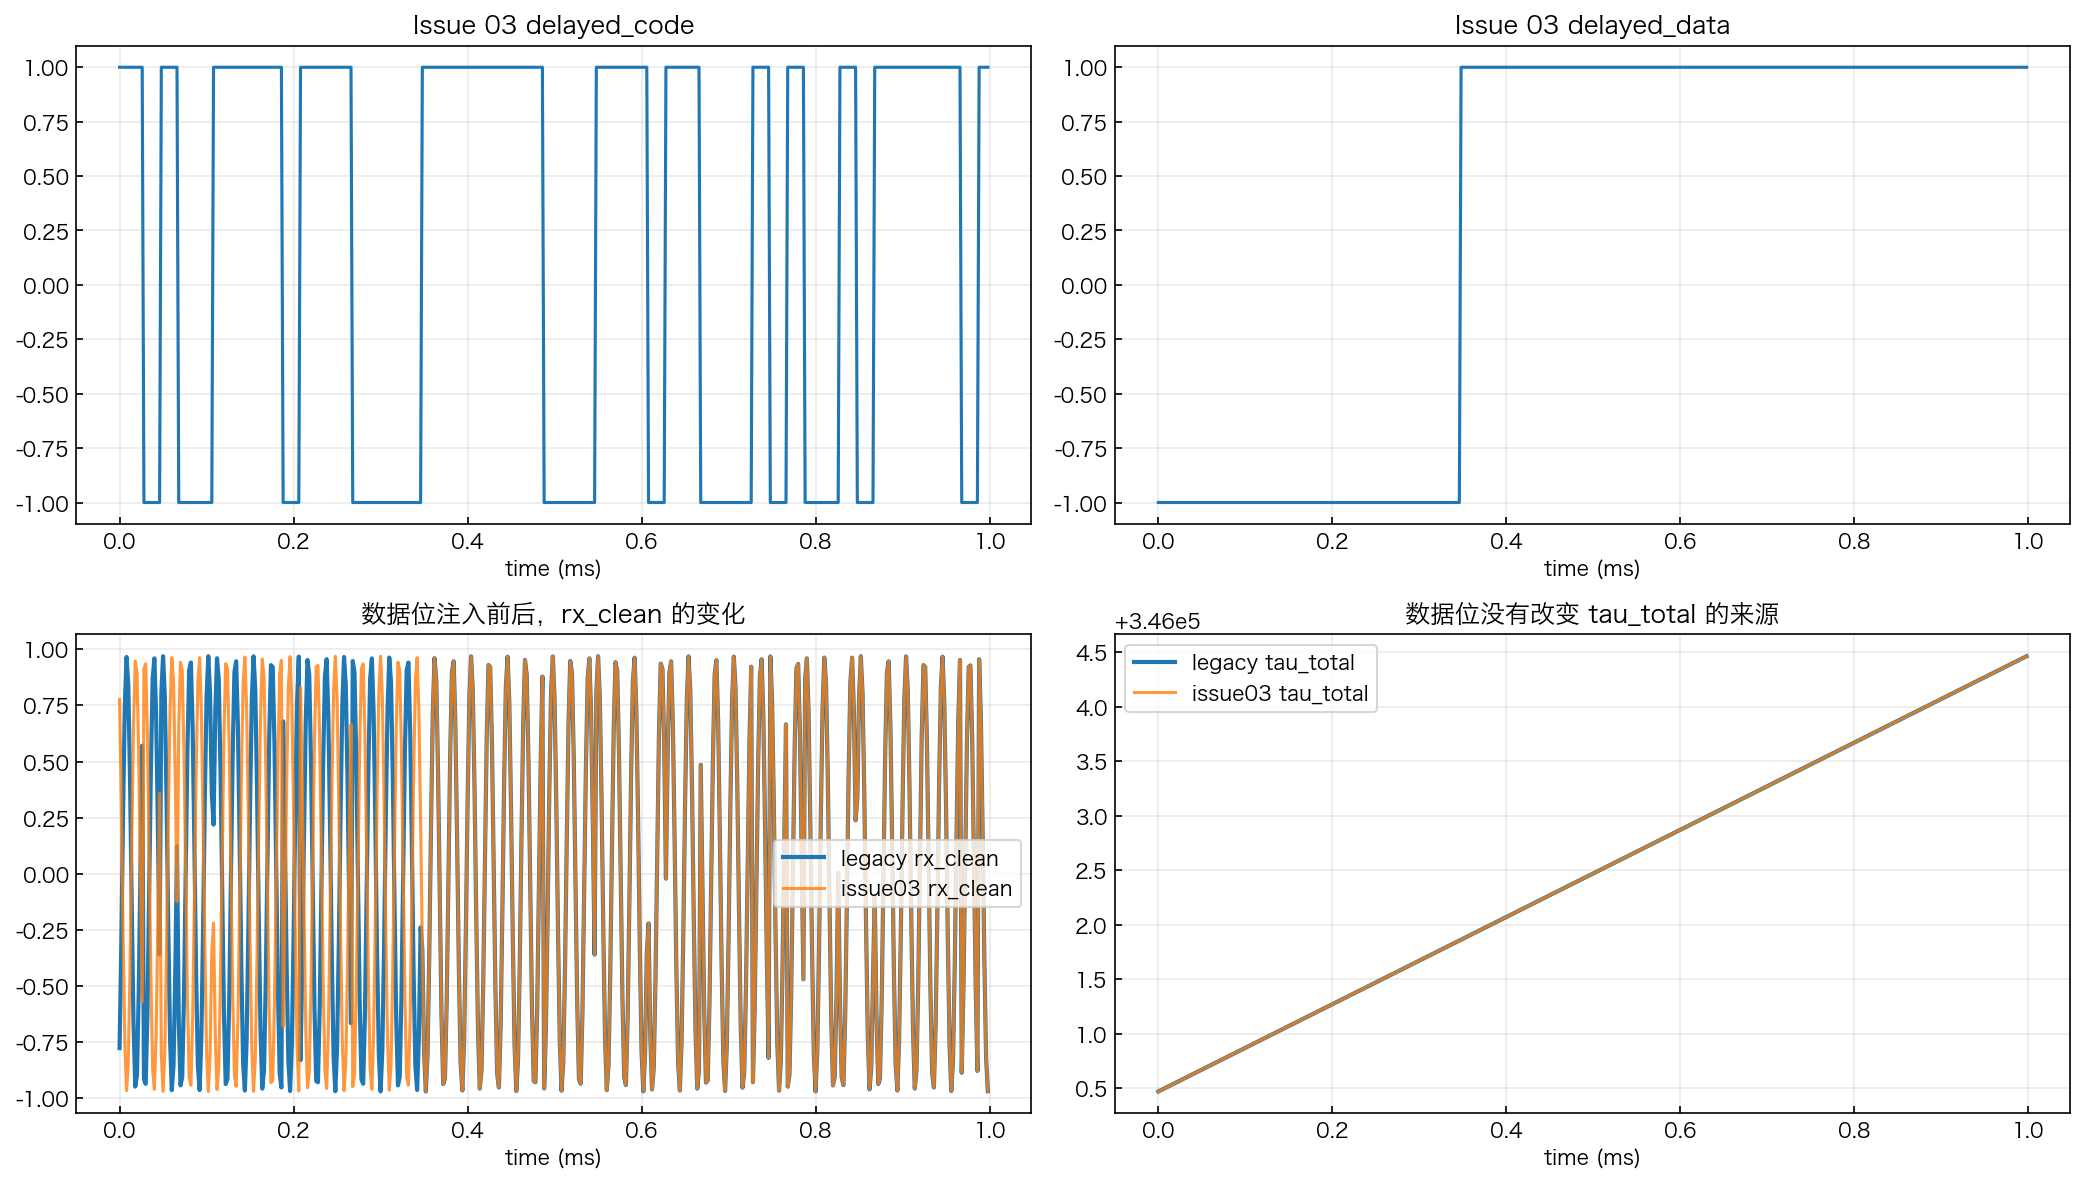

In [11]:
cfg_sig_issue03 = ISSUE03.build_textbook_signal_config(FC_HZ, wkb_result['wkb_time_s'], nav_data_enabled=True)
nav_data_model = ISSUE03.build_navigation_data_model(cfg_sig_issue03, rng_seed=TRACE_RNG_SEED)
issue03_trace = ISSUE03.build_textbook_signal_block_trace(
    t_block_s=t_block_s,
    code_chips=code_chips,
    cfg_sig=cfg_sig_issue03,
    cfg_motion=cfg_motion,
    plasma_rx=plasma_rx,
    global_rx_time_s=rx_time_s,
    nav_data_model=nav_data_model,
    rng=np.random.default_rng(TRACE_RNG_SEED),
)

print({
    'bit_rate_bps': nav_data_model.bit_rate_bps,
    'bit_period_s': nav_data_model.bit_period_s,
    'nav_symbols_preview': nav_data_model.symbols[:8].tolist(),
})

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(t_block_s[:500] * 1e3, issue03_trace.delayed_code[:500].real)
axes[0, 0].set_title('Issue 03 delayed_code')
axes[0, 0].set_xlabel('time (ms)')

axes[0, 1].plot(t_block_s[:500] * 1e3, issue03_trace.delayed_data[:500].real)
axes[0, 1].set_title('Issue 03 delayed_data')
axes[0, 1].set_xlabel('time (ms)')

axes[1, 0].plot(t_block_s[:500] * 1e3, legacy_trace.rx_clean[:500].real, label='legacy rx_clean', lw=2)
axes[1, 0].plot(t_block_s[:500] * 1e3, issue03_trace.rx_clean[:500].real, label='issue03 rx_clean', alpha=0.8)
axes[1, 0].set_title('数据位注入前后，rx_clean 的变化')
axes[1, 0].set_xlabel('time (ms)')
axes[1, 0].legend()

axes[1, 1].plot(t_block_s[:500] * 1e3, legacy_trace.tau_total_s[:500] * 1e9, label='legacy tau_total', lw=2)
axes[1, 1].plot(t_block_s[:500] * 1e3, issue03_trace.tau_total_s[:500] * 1e9, label='issue03 tau_total', alpha=0.8)
axes[1, 1].set_title('数据位没有改变 tau_total 的来源')
axes[1, 1].set_xlabel('time (ms)')
axes[1, 1].legend()

fig.tight_layout()
plt.show()


## 11. 主线小结

把当前真实信号层压缩成一句话，就是：

1. `m-sequence` 提供可复现的离散码。
2. `sample_code_waveform()` 把它变成连续时间的矩形 chip 周期波形。
3. 真实接收块先形成 `delayed_code = c(t - tau_total)`。
4. 然后再乘 `A(t)` 和 `exp(j phase_total)`，得到 `rx_clean`。
5. 最后加上噪声，得到 `rx_block`。

所以当前真实信号主线的核心不是“先谈一堆时延名词”，而是：

**同一个本地可复现码，经过连续时间采样、延迟采样、幅度和相位调制，再加噪声，才变成接收机真正看到的复基带块。**

# 附录：`BOC / BCS`

> 附录中的图是概念演示，不代表当前仓库真实信号链已经实现 `BOC` 或 `BCS`。

## A1. 为什么 `BOC / BCS` 值得看

它们之所以还值得放一个附录，是因为它们展示了一个很关键的设计思想：

- 如果一个 chip 内部继续细分结构，自相关和频谱都会随之变化。
- 这会影响测距主峰形状、旁峰、谱形和实现复杂度。

但在当前仓库里，这仍然只是概念参考，不是可执行事实。

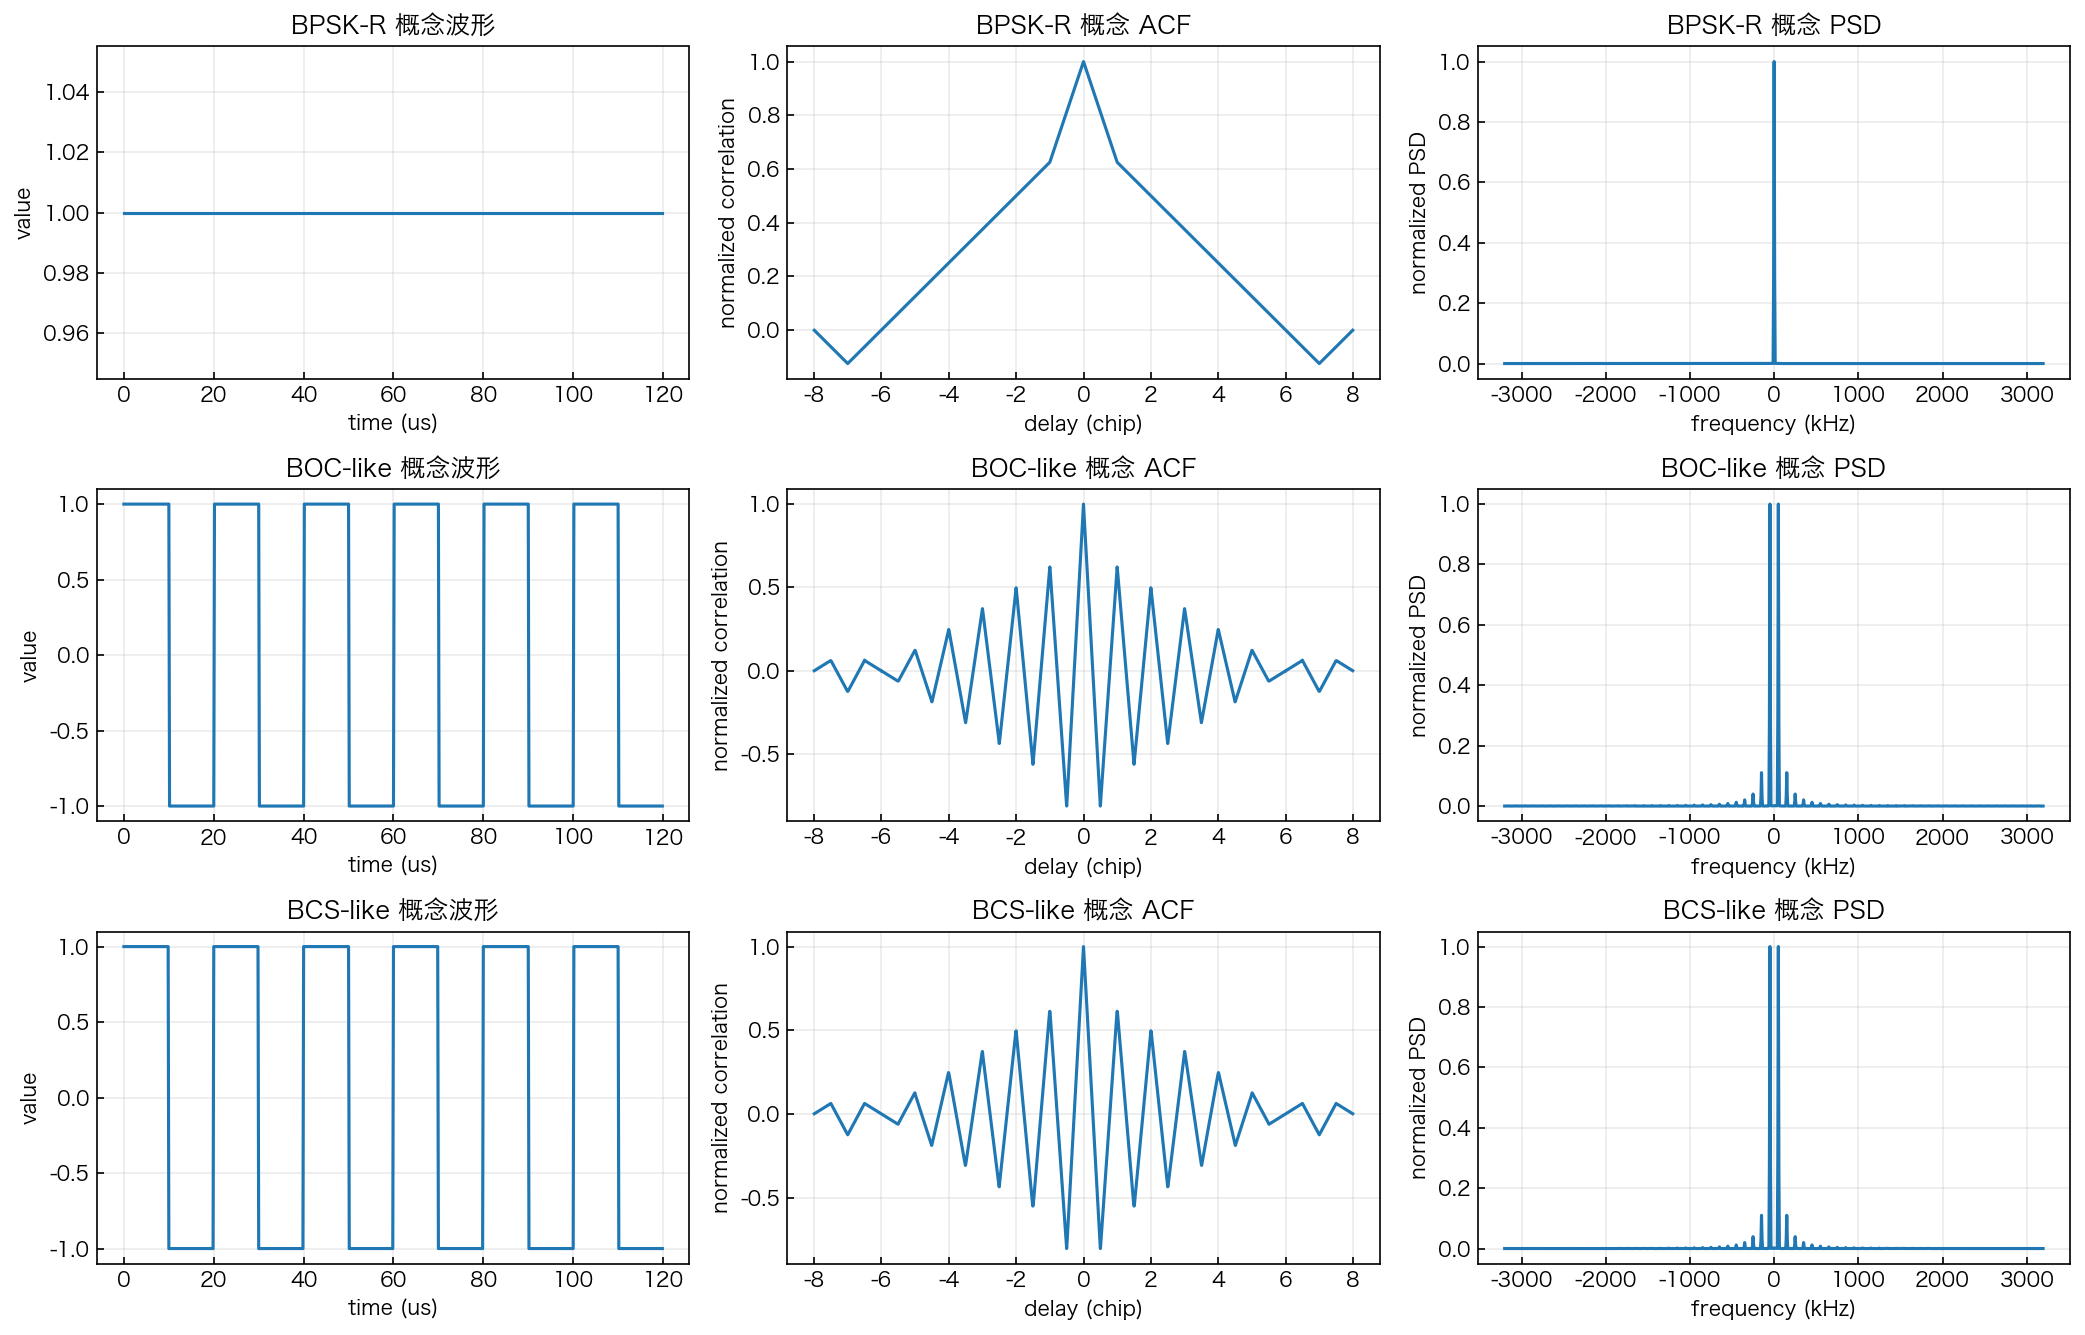

In [12]:
code_short = code[:8]
oversample = 128
samples_per_chip = oversample
t = np.arange(len(code_short) * samples_per_chip) / (chip_rate_hz * samples_per_chip)
bpsk_wave = np.repeat(code_short, samples_per_chip)
boc_wave = boc_like_waveform(bpsk_wave, t, fs_hz=chip_rate_hz, phase_rad=0.0)
t_bcs, bcs_wave = bcs_like_waveform(code_short, chip_rate_hz=chip_rate_hz, template=np.array([1.0, 1.0, -1.0, -1.0]), oversample=32)

lags_bpsk, acf_bpsk = normalized_sliding_autocorr(bpsk_wave)
lags_boc, acf_boc = normalized_sliding_autocorr(boc_wave)
lags_bcs, acf_bcs = normalized_sliding_autocorr(bcs_wave)

freq_bpsk = np.fft.fftshift(np.fft.fftfreq(len(bpsk_wave), d=t[1] - t[0]))
psd_bpsk = np.abs(np.fft.fftshift(np.fft.fft(bpsk_wave * np.hanning(len(bpsk_wave))))) ** 2
freq_boc = np.fft.fftshift(np.fft.fftfreq(len(boc_wave), d=t[1] - t[0]))
psd_boc = np.abs(np.fft.fftshift(np.fft.fft(boc_wave * np.hanning(len(boc_wave))))) ** 2
freq_bcs = np.fft.fftshift(np.fft.fftfreq(len(bcs_wave), d=t_bcs[1] - t_bcs[0]))
psd_bcs = np.abs(np.fft.fftshift(np.fft.fft(bcs_wave * np.hanning(len(bcs_wave))))) ** 2

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes[0, 0].plot(t[: 6 * samples_per_chip] * 1e6, bpsk_wave[: 6 * samples_per_chip])
axes[0, 0].set_title('BPSK-R 概念波形')
axes[1, 0].plot(t[: 6 * samples_per_chip] * 1e6, boc_wave[: 6 * samples_per_chip])
axes[1, 0].set_title('BOC-like 概念波形')
axes[2, 0].plot(t_bcs[: 6 * 32 * 4] * 1e6, bcs_wave[: 6 * 32 * 4])
axes[2, 0].set_title('BCS-like 概念波形')

axes[0, 1].plot(lags_bpsk / samples_per_chip, acf_bpsk)
axes[0, 1].set_title('BPSK-R 概念 ACF')
axes[1, 1].plot(lags_boc / samples_per_chip, acf_boc)
axes[1, 1].set_title('BOC-like 概念 ACF')
axes[2, 1].plot(lags_bcs / (32 * 4), acf_bcs)
axes[2, 1].set_title('BCS-like 概念 ACF')

axes[0, 2].plot(freq_bpsk / 1e3, psd_bpsk / np.max(psd_bpsk))
axes[0, 2].set_title('BPSK-R 概念 PSD')
axes[1, 2].plot(freq_boc / 1e3, psd_boc / np.max(psd_boc))
axes[1, 2].set_title('BOC-like 概念 PSD')
axes[2, 2].plot(freq_bcs / 1e3, psd_bcs / np.max(psd_bcs))
axes[2, 2].set_title('BCS-like 概念 PSD')

for ax in axes[:, 0]:
    ax.set_xlabel('time (us)')
    ax.set_ylabel('value')
for ax in axes[:, 1]:
    ax.set_xlabel('delay (chip)')
    ax.set_ylabel('normalized correlation')
for ax in axes[:, 2]:
    ax.set_xlabel('frequency (kHz)')
    ax.set_ylabel('normalized PSD')

fig.tight_layout()
plt.show()
